In [21]:
%pip install gymnasium

In [22]:
!pip uninstall tensorflow -y
!pip install tensorflow==2.16.2 matplotlib==3.9.1 "numpy<2.0"
!pip install jax==0.4.29 jaxlib==0.4.29 ml_dtypes --upgrade

Found existing installation: tensorflow 2.16.2
Uninstalling tensorflow-2.16.2:
  Successfully uninstalled tensorflow-2.16.2
  Using cached tensorflow-2.16.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached tensorflow-2.16.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (590.8 MB)
Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.2 MB)
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.4
    Uninstalling ml_dtypes-0.5.4:
      Successfully uninstalled ml_dtypes-0.5.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.4.29 requires ml-dtypes>=0.4.0, but you have ml-dtypes 0.3.2 which is incompatible.
jax 0.4.29 requires ml-dtypes

  Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (5.0 MB)
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.16.2 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.16.2 which is incompatible.
orbax-checkpoint 0.11.40 requires jax>=0.6.0, but you have jax 0.4.29 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but yo

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [2]:
import sys
sys.setrecursionlimit(1500)

import gymnasium as gym
import numpy as np

# Create the environment
env = gym.make('CartPole-v1')

# Set random seed for reproducibility
np.random.seed(42)
env.action_space.seed(42)
env.observation_space.seed(42)

42

In [18]:
# Suppress warnings for a cleaner notebook or console experience
import warnings
warnings.filterwarnings('ignore')

# Override the default warning function
def warn(*args, **kwargs):
    pass
warnings.warn = warn

# Import necessary libraries for the Q-Learning model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input  # Import Input layer
from tensorflow.keras.optimizers import Adam
import gymnasium as gym  # Ensure the environment library is available
deep_model_rewards = []  # Your tracking list
small_model_rewards = []  # Your tracking list

# Define the model building function
def build_model_small(state_size, action_size):
    model = Sequential()
    model.add(Input(shape=(state_size,)))  # Use Input layer to specify the input shape
    model.add(Dense(24, activation='relu'))
    model.add(Dense(24, activation='relu'))
    model.add(Dense(action_size, activation='linear'))
    model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
    return model

# Create the environment and set up the model
env = gym.make('CartPole-v1')
state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)
model = build_model_small(state_size, action_size)

In [19]:
# Implement a Q-learning Algorithm

import random
import numpy as np
from collections import deque
import tensorflow as tf

# Define epsilon and epsilon_decay
epsilon = 1.0  # Starting with a high exploration rate
epsilon_min = 0.01  # Minimum exploration rate
epsilon_decay = 0.995  # Faster decay rate for epsilon after each episode

# Replay memory
memory = deque(maxlen=2000)

def remember(state, action, reward, next_state, done):
    """Store experience in memory."""
    memory.append((state, action, reward, next_state, done))

def replay(batch_size=64):  # Increased batch size
    """Train the model using a random sample of experiences from memory."""
    if len(memory) < batch_size:
        return  # Skip replay if there's not enough experience

    minibatch = random.sample(memory, batch_size)  # Sample a random batch from memory

    # Extract information for batch processing
    states = np.vstack([x[0] for x in minibatch])
    actions = np.array([x[1] for x in minibatch])
    rewards = np.array([x[2] for x in minibatch])
    next_states = np.vstack([x[3] for x in minibatch])
    dones = np.array([x[4] for x in minibatch])

    # Predict Q-values for the next states in batch
    q_next = model.predict(next_states)
    # Predict Q-values for the current states in batch
    q_target = model.predict(states)

    # Vectorized update of target values
    for i in range(batch_size):
        target = rewards[i]
        if not dones[i]:
            target += 0.95 * np.amax(q_next[i])  # Update Q value with the discounted future reward
        q_target[i][actions[i]] = target  # Update only the taken action's Q value

    # Train the model with the updated targets in batch
    model.fit(states, q_target, epochs=1, verbose=0)  # Train in batch mode

# Function to adjust epsilon based on performance
def adjust_epsilon(score, consecutive_success_threshold=200):
    global epsilon

    if score >= consecutive_success_threshold:
        epsilon = max(epsilon_min, epsilon * 0.9)  # Reduce epsilon faster if performance is good
    else:
        epsilon = max(epsilon_min, epsilon * epsilon_decay)  # Regular epsilon decay

episodes = 2  # Set number of episodes for training

def act(state):
    """Choose an action based on the current state and exploration rate."""
    if np.random.rand() <= epsilon:
        return random.randrange(action_size)  # Explore: choose a random action
    act_values = model.predict(state)  # Exploit: predict action based on the state
    return np.argmax(act_values[0])  # Return the action with the highest Q-value

def train_and_capture_rewards(model, episodes=10, train_frequency=5):
  # This list will store the total reward for every single episode
  #small_model_rewards = []  # Your tracking list

  # Define the number of episodes you want to train the model for
  episodes = 100  # You can set this to any number you prefer
  train_frequency = 5  # Train the model every 5 steps

  for e in range(episodes):
      state, _ = env.reset()  # Unpack the tuple returned by env.reset()
      state = np.reshape(state, [1, state_size])
      total_reward = 0  # Track raw un-penalized score
      for time in range(200):  # Limit to 200 time steps per episode
          action = act(state)
          next_state, reward, terminated, truncated, _ = env.step(action)
          done = terminated or truncated

          total_reward += reward  # Keep track of the raw steps survived

          target_reward = reward if not done else -10
          next_state = np.reshape(next_state, [1, state_size])
          remember(state, action, target_reward, next_state, done)  # Store experience
          state = next_state

          if done:
              adjust_epsilon(total_reward)  # Adjust epsilon based on the total reward
              print(f"episode: {e+1}/{episodes}, Total Reward: {total_reward}, score: {time}, e: {epsilon:.2}")
              break

          # Train the model every 'train_frequency' steps
          if time % train_frequency == 0:
              replay(batch_size=64)  # Call replay with larger batch size for efficiency

      # Append the final un-penalized score to our history list
      small_model_rewards.append(total_reward)
      #print(f'Episode Reward: {episode_rewards}')
  return small_model_rewards

# 1. Train the Original Small Model (32x32)
print("--- Training Original Model ---")
rewards_small = train_and_capture_rewards(model, episodes=50)
print(f'Small Model Rewards: {rewards_small}')
env.close()

--- Training Original Model ---
episode: 1/100, Total Reward: 21.0, score: 20, e: 0.99
episode: 2/100, Total Reward: 18.0, score: 17, e: 0.99
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
episode: 3/100, Total Reward: 42.0, score: 41, e: 0.99
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
episode: 4/100, Total Reward: 19.0, score: 18, e: 0.98
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0

In [20]:
# Initialize the environment
env = gym.make('CartPole-v1')

# Global settings
episodes = 100  # Number of episodes
batch_size = 64  # Size of the mini-batch for training
memory = deque(maxlen=2000)  # Memory buffer to store experiences

# Define state size and action size based on the environment
state_size = int(env.observation_space.shape[0])  # State space size from the environment
action_size = int(env.action_space.n)  # Number of possible actions from the environment

# Define the model
def build_model_deep(state_size, action_size):
    model = Sequential()
    model.add(Input(shape=(state_size,)))  # Explicit Input layer
    model.add(Dense(64, activation='relu'))  # Smaller hidden layers
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(action_size, activation='linear'))
    model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
    return model

# Re-initialize the model with the new architecture
model = build_model_deep(state_size, action_size)

# Placeholder for your action function (e.g., epsilon-greedy)
def act(state):
    return env.action_space.sample()  # For now, a random action is taken

# Function to remember experiences in memory
def remember(state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))

# Optimized function to replay experiences from memory and train the model
def replay(batch_size):
    minibatch = random.sample(memory, batch_size)
    states = np.vstack([sample[0] for sample in minibatch])
    next_states = np.vstack([sample[3] for sample in minibatch])
    targets = model.predict(states)
    target_next = model.predict(next_states)

    for i, (state, action, reward, next_state, done) in enumerate(minibatch):
        target = reward if done else reward + 0.95 * np.amax(target_next[i])
        targets[i][action] = target

    model.fit(states, targets, epochs=1, verbose=0)

# This list will store the total reward for every single episode
#deep_model_rewards = []  # Your tracking list

# Train the model with the modified architecture
for e in range(episodes):
    state, _ = env.reset()  # Unpack the state from the tuple
    state = np.reshape(state, [1, state_size])
    total_reward = 0
    for time in range(200):  # Reduced number of steps per episode
        action = act(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward  # Keep accumulating 1.0 per step
        target_reward = reward if not done else -10
        next_state = np.reshape(next_state, [1, state_size])
        remember(state, action, target_reward, next_state, done)
        state = next_state

        if done:
            adjust_epsilon(total_reward)  # Adjust epsilon based on the total reward
            print(f"episode: {e+1}/{episodes},Total Reward: {total_reward}, score: {time}")
            break

        if len(memory) > batch_size and time % 10 == 0:  # Train every 10 steps
            replay(batch_size)  # Pass the batch size to replay()

    # Append the final un-penalized score to our history list
    deep_model_rewards.append(total_reward)

print(f'Deep Model Rewards: {deep_model_rewards}')
env.close()

episode: 1/100,Total Reward: 13.0, score: 12
episode: 2/100,Total Reward: 12.0, score: 11
episode: 3/100,Total Reward: 14.0, score: 13
episode: 4/100,Total Reward: 17.0, score: 16
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
episode: 5/100,Total Reward: 44.0, score: 43
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
episode: 6/100,Total Reward: 41.0, score: 40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
2/2 ━━━━

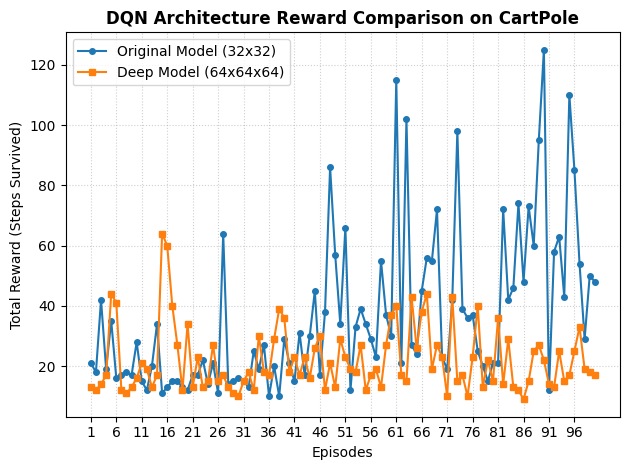

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    'Original Model (32x32)': small_model_rewards,
    'Deep Model (64x64x64)': deep_model_rewards
})

# 1. Plot lines with smaller markers so the 50 points don't look overly cluttered
plt.plot(df['Original Model (32x32)'], marker='o', markersize=4, label='Original Model (32x32)', linewidth=1.5)
plt.plot(df['Deep Model (64x64x64)'], marker='s', markersize=4, label='Deep Model (64x64x64)', linewidth=1.5)

# 2. Fix the X-Axis Labels (Dynamic spacing for 50 episodes)
# This labels every 5th episode starting from 1 up to the total length
plt.xticks(
    range(0, len(df), 5),
    labels=[str(i+1) for i in range(0, len(df), 5)]
)

plt.title('DQN Architecture Reward Comparison on CartPole', fontsize=12, fontweight='bold')
plt.xlabel('Episodes', fontsize=10)
plt.ylabel('Total Reward (Steps Survived)', fontsize=10)

plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()